In [1]:
# Setup and imports
import sys
sys.path.append("..")  # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.cleaner import clean_pipeline
from src.data.features import feature_pipeline

sns.set_style("whitegrid")

In [2]:
# Load and clean
df_raw = pd.read_csv("../data/raw/hillstrom.csv")
print(f"Raw shape: {df_raw.shape}")

df_clean = clean_pipeline(df_raw)
print(f"Clean shape: {df_clean.shape}")
df_clean.head()

Raw shape: (64000, 13)
Clean shape: (64000, 13)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.440002,1,0,Surburban,0,Phone,Womens E-Mail,1,0,0,0.0
1,6,3) $200 - $350,329.079987,1,1,Rural,1,Web,No E-Mail,0,0,0,0.0
2,7,2) $100 - $200,180.649994,0,1,Surburban,1,Web,Womens E-Mail,1,0,0,0.0
3,9,5) $500 - $750,675.830017,1,0,Rural,1,Web,Mens E-Mail,1,0,0,0.0
4,2,1) $0 - $100,45.340000,1,0,Urban,0,Web,Womens E-Mail,1,0,0,0.0


In [3]:
# Verify if cleaning worked
print("Columns after cleaning:")
print(df_clean.columns.tolist())
print(f"\nTreatment distribution:\n{df_clean['treatment'].value_counts()}")
print(f"\nDtypes:\n{df_clean.dtypes}")

Columns after cleaning:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'treatment', 'visit', 'conversion', 'spend']

Treatment distribution:
treatment
1    42694
0    21306
Name: count, dtype: int64

Dtypes:
recency              int64
history_segment        str
history            float32
mens                  int8
womens                int8
zip_code               str
newbie                int8
channel                str
segment                str
treatment             int8
visit                 int8
conversion            int8
spend              float32
dtype: object


In [4]:
# Feature engineering
df_feat = feature_pipeline(df_clean)
print(f"Feature-engineered shape: {df_feat.shape}")
df_feat.head()

Feature-engineered shape: (64000, 20)


,recency,history_segment,history,mens,womens,zip_code,newbie,segment,treatment,visit,conversion,spend,channel_multichannel,channel_phone,channel_web,zip_code_original,history_segment_code,category_count,recency_bin,history_bin
0,10,2) $100 - $200,142.440002,1,0,-1,0,Womens E-Mail,1,0,0,0.0,0,1,0,Surburban,1,1,3,1
1,6,3) $200 - $350,329.079987,1,1,0,1,No E-Mail,0,0,0,0.0,0,0,1,Rural,2,2,1,3
2,7,2) $100 - $200,180.649994,0,1,-1,1,Womens E-Mail,1,0,0,0.0,0,0,1,Surburban,1,1,2,2
3,9,5) $500 - $750,675.830017,1,0,0,1,Mens E-Mail,1,0,0,0.0,0,0,1,Rural,4,1,2,3
4,2,1) $0 - $100,45.340000,1,0,2,0,Womens E-Mail,1,0,0,0.0,0,0,1,Urban,0,1,0,0


In [5]:
# Inspect new features
print("New columns added:")
new_cols = set(df_feat.columns) - set(df_clean.columns)
print(sorted(new_cols))

print(f"\ncategory_count distribution:\n{df_feat['category_count'].value_counts().sort_index()}")
print(f"\nrecency_bin distribution:\n{df_feat['recency_bin'].value_counts().sort_index()}")
print(f"\nhistory_segment_code distribution:\n{df_feat['history_segment_code'].value_counts().sort_index()}")

New columns added:
['category_count', 'channel_multichannel', 'channel_phone', 'channel_web', 'history_bin', 'history_segment_code', 'recency_bin', 'zip_code_original']

category_count distribution:
category_count
1    57552
2     6448
Name: count, dtype: int64

recency_bin distribution:
recency_bin
0    16489
1    20096
2    14014
3    13401
Name: count, dtype: int64

history_segment_code distribution:
history_segment_code
-1     1308
 0    22970
 1    14254
 2    12289
 3     6409
 4     4911
 5     1859
Name: count, dtype: int64


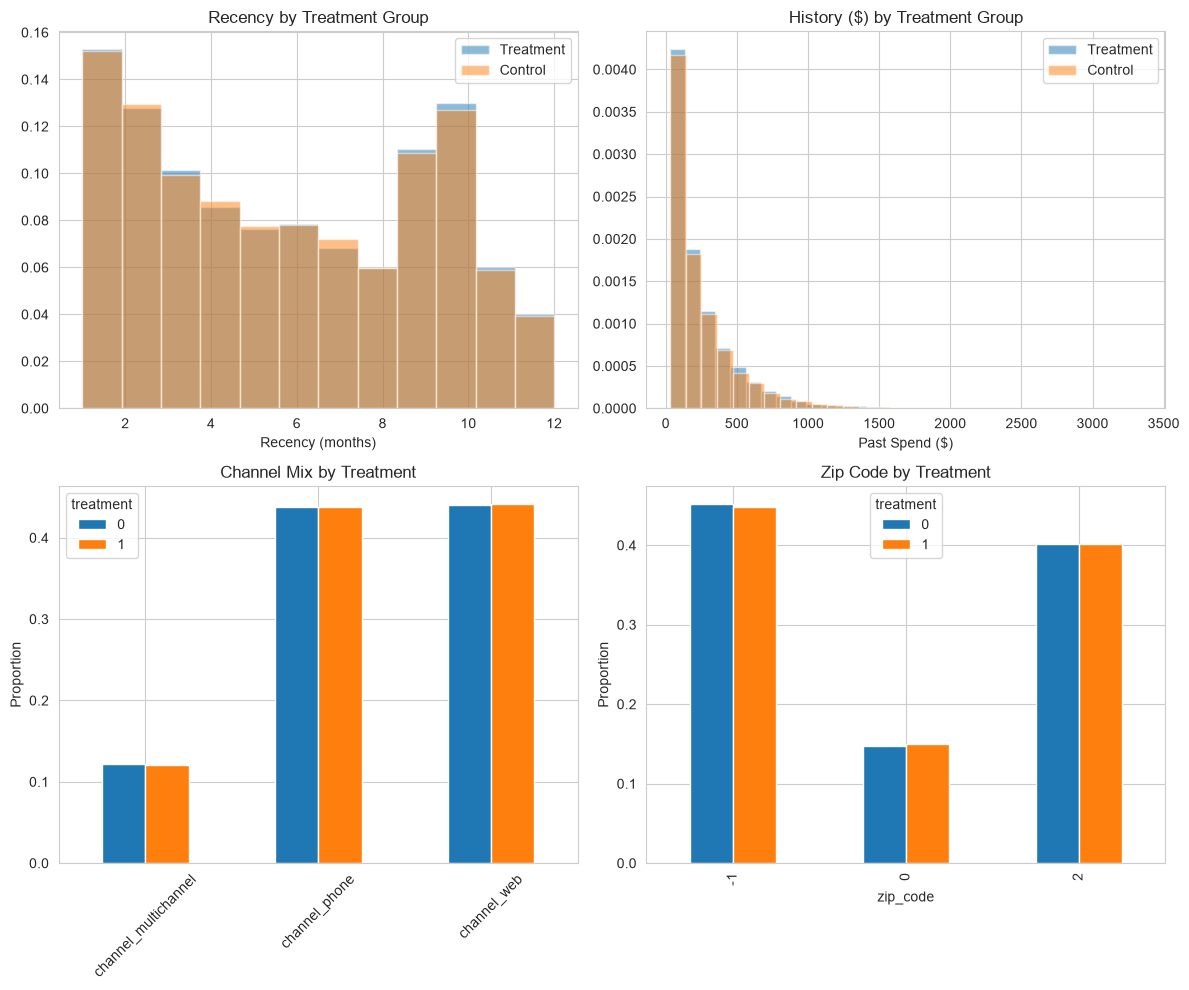

Plot saved to artifacts/plots/


In [6]:
# Visualize key distributions by treatment group
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Recency distribution by treatment
axes[0, 0].set_title("Recency by Treatment Group")
for t, label in [(1, "Treatment"), (0, "Control")]:
    subset = df_feat[df_feat["treatment"] == t]
    axes[0, 0].hist(subset["recency"], bins=12, alpha=0.5, label=label, density=True)
axes[0, 0].legend()
axes[0, 0].set_xlabel("Recency (months)")

# History distribution by treatment
axes[0, 1].set_title("History ($) by Treatment Group")
for t, label in [(1, "Treatment"), (0, "Control")]:
    subset = df_feat[df_feat["treatment"] == t]
    axes[0, 1].hist(subset["history"], bins=30, alpha=0.5, label=label, density=True)
axes[0, 1].legend()
axes[0, 1].set_xlabel("Past Spend ($)")

# Channel distribution by treatment
channel_cols = [c for c in df_feat.columns if c.startswith("channel_")]
channel_means = df_feat.groupby("treatment")[channel_cols].mean()
channel_means.T.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Channel Mix by Treatment")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].tick_params(axis='x', rotation=45)

# Zip code distribution by treatment
zip_means = df_feat.groupby("treatment")["zip_code"].value_counts(normalize=True).unstack()
zip_means.T.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Zip Code by Treatment")
axes[1, 1].set_ylabel("Proportion")

plt.tight_layout()
plt.savefig("../artifacts/plots/feature_distributions_by_treatment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to artifacts/plots/")

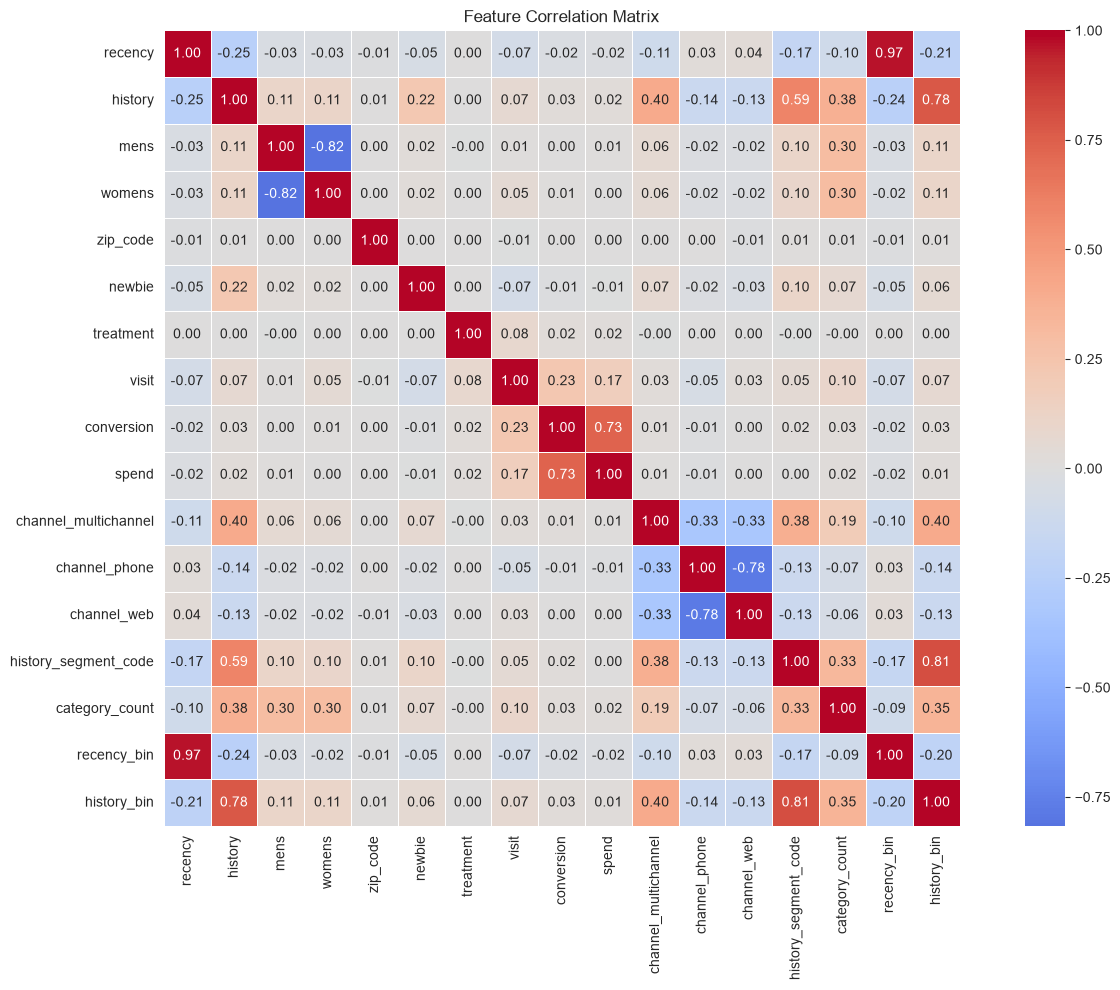

In [7]:
# Correlation heat map
numeric_cols = df_feat.select_dtypes(include=[np.number]).columns
corr = df_feat[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../artifacts/plots/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Export processed data
# Define which columns to keep for modeling
# Drop the original string columns that have been encoded
drop_cols = ["segment", "history_segment", "zip_code_original"]
df_export = df_feat.drop(columns=drop_cols)

# Save
df_export.to_csv("../data/processed/customers_features.csv", index=False)
print(f"Exported shape: {df_export.shape}")
print(f"Columns: {df_export.columns.tolist()}")
print(f"\nSaved to data/processed/customers_features.csv")

Exported shape: (64000, 17)
Columns: ['recency', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'treatment', 'visit', 'conversion', 'spend', 'channel_multichannel', 'channel_phone', 'channel_web', 'history_segment_code', 'category_count', 'recency_bin', 'history_bin']

Saved to data/processed/customers_features.csv


In [9]:
# Final sanity check
# Reload and verify
df_check = pd.read_csv("../data/processed/customers_features.csv")
assert df_check.shape == df_export.shape, "Shape mismatch after save/reload!"
assert df_check.isnull().sum().sum() == 0, "Nulls found after feature engineering!"
print(f"✓ Verified: {df_check.shape[0]} rows, {df_check.shape[1]} columns, 0 nulls")
print(f"✓ Treatment split: {df_check['treatment'].value_counts().to_dict()}")

✓ Verified: 64000 rows, 17 columns, 0 nulls
✓ Treatment split: {1: 42694, 0: 21306}


In [10]:
from sklift.datasets import fetch_hillstrom
d1 = fetch_hillstrom(target_col='visit')
print("Data shape:", d1['data'].shape)
print("Treatment dtype:", d1['treatment'].dtype)
print("Treatment unique:", d1['treatment'].unique())
print("Treatment value counts:\n", d1['treatment'].value_counts())

Data shape: (64000, 8)
Treatment dtype: str
Treatment unique: <StringArray>
['Womens E-Mail', 'No E-Mail', 'Mens E-Mail']
Length: 3, dtype: str
Treatment value counts:
 segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64
